# Regressão Linear Simples

In [1]:
import kagglehub
import glob

# Download latest version
path = kagglehub.dataset_download("rsadiq/salary")
csv_files = glob.glob(path + "/*.csv")


100%|██████████| 392/392 [00:00<00:00, 1.02MB/s]

Extracting files...


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv(csv_files[0])

In [3]:
class LinearRegression:
    def __init__(self, a = 0, b = 0):
        self.weight = a
        self.bias = b
        self.learning_rate = 0.1
        self.max_iterations = 1000
        self.error_tolerance = 0.00001

    def __calc_y(self, x_train):
        return self.weight * x_train + self.bias
    

    def __update_parameters(self, x_train, y_train):
        y_pred = self.__calc_y(x_train)
        diff = y_pred - y_train

        mse_weight = np.sum(diff * x_train) * (2/len(x_train))
        new_weight = self.weight - (self.learning_rate * mse_weight)

        mse_bias = np.sum(diff) * (2/len(x_train))
        new_bias = self.bias - (self.learning_rate * mse_bias)

        self.weight = new_weight
        self.bias = new_bias

    
    def __calc_mse(self, x_train, y_train):
        y_pred = self.__calc_y(x_train)
        diff = y_pred - y_train
        mse = np.sum((diff)**2) / len(x_train)

        return mse
    

    def __calc_gradient(self, x_train,y_train):
        previous_mse = self.__calc_mse(x_train, y_train)
        count = 0
         
        while count < self.max_iterations:
            self.__update_parameters(x_train, y_train)
            new_mse = self.__calc_mse(x_train, y_train)
            
            diff = abs(new_mse - previous_mse)

            if diff < self.error_tolerance:
                break

            previous_mse = new_mse
            count += 1

        print("Quantidade de iterações: ", count)
        print("MSE final: ", new_mse)
        print("RMSE Final: ", np.sqrt(new_mse))

    def predict(self, x_test):
        return self.__calc_y(x_test)
            
    
    def fit(self, x_train, y_train):
        self.__calc_gradient(x_train, y_train)



Nesse modelo, o treinamento por gradiente descendente foi realizado utilizando o MSE. Com isso, os erros maiores (outliers) terão mais impacto no ajuste dos parâmetros.

Além disso, o learning rate foi definido experimentalmente como 0.1. Esse valor apresentou-se como o mais adequado para os dados normalizados, já que o MSE apresentou uma queda contínua a cada iteração (sem oscilações ou crescimento), dentro de um limite máximo de 1000 iterações, saindo de, aproximadamente, 1.07 para valores próximos de 0.04.

Por fim, foi utilizada uma tolerância de erro (error_tolerance) igual a 0.00001, permitindo que o treinamento fosse interrompido quando a melhora entre as iterações se tornasse muito pequena, evitasndo, assim, iterações desnecessárias.

In [12]:
x = df["YearsExperience"]
y = df["Salary"]

# Normalização das variáveis
x_norm = (x - x.mean()) / x.std()
y_norm = (y - y.mean()) / y.std()

# Separação de teste e treino
x_train, x_test, y_train, y_test = train_test_split(x_norm, y_norm, test_size=0.3, random_state=0)


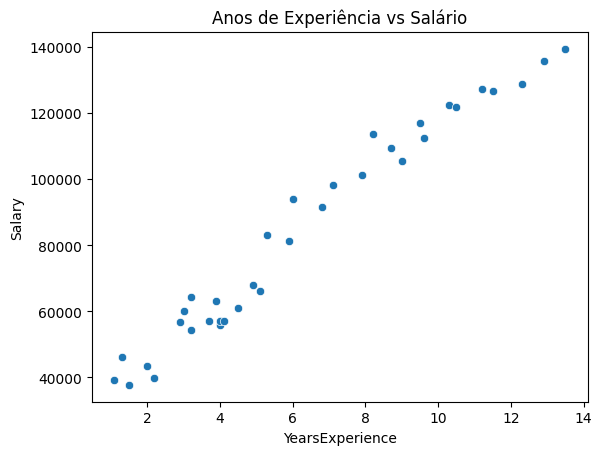

In [10]:
import seaborn as sns
sns.scatterplot(x="YearsExperience", y="Salary", data=df)
plt.title("Anos de Experiência vs Salário")
plt.show()

Com o gráfico "Anos de Experiência vs Salário" podemos ver que as variáveis possuem uma relação linear. Com isso, podemos usar o algoritmo de regressão linear simples para prever o salário a partir dos anos de experiência.

In [11]:
# Teste e treino
model = LinearRegression()
model.fit(x_train, y_train)
y_pred_norm = model.predict(x_test)


Quantidade de iterações:  22
MSE final:  0.040745903172992766
RMSE Final:  0.20185614474915736


Como o learning rate foi de 0.1 (um pouco alto), ele só necessitou de 22 iterações. Porém, os dados foram normalizados para que o treinamento do modelo fosse mais estável.

In [5]:
y_real = y_test * y.std() + y.mean()
y_pred = y_pred_norm * y.std() + y.mean()

r2 = r2_score(y_real, y_pred)
mae = mean_absolute_error(y_real, y_pred)
mse = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))


print("R²: ", r2)
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)

R²:  0.9710516149152566
MAE:  3857.792050683178
MSE:  22257227.089234337
RMSE:  4717.756573757736


As métricas de avaliação indicam que o modelo apresentou um bom desempenho no conjunto de teste. O valor de R² foi aproximadamente 0,97, o que significa que o modelo conseguiu representar cerca de 97% da variação dos salários a partir dos anos de experiência. Além disso, o RMSE foi de 4.717, ou seja, em média, as previsões do modelo se afastam dos valores reais em cerca de 4.717 dólares.

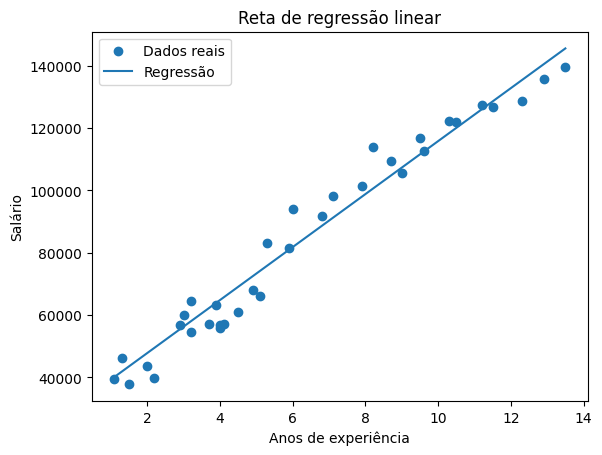

In [6]:
import matplotlib.pyplot as plt

plt.scatter(x, y, label="Dados reais")

x_line = np.linspace(x.min(), x.max(), 100)
x_line_norm = (x_line - x.mean()) / x.std()
y_line_norm = model.predict(x_line_norm)
y_line = y_line_norm * y.std() + y.mean()

plt.plot(x_line, y_line, label="Regressão")
plt.xlabel("Anos de experiência")
plt.ylabel("Salário")
plt.title("Reta de regressão linear")
plt.legend()
plt.show()

Esse gráfico apresenta o que as métricas já indicavam: o modelo apresenta previsões bem próximas dos valores reais. A proximidade entre os pontos e a tendência esperada reforça que a regressão linear conseguiu representar bem a relação entre anos de experiência e salário.

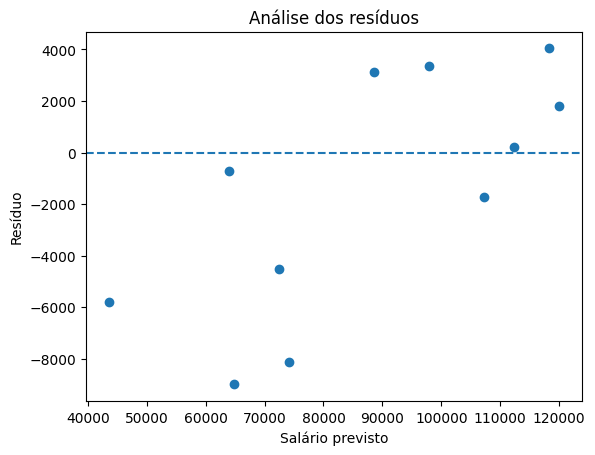

In [8]:
residuos = y_real - y_pred

plt.scatter(y_pred, residuos)
plt.axhline(0, linestyle="--")
plt.xlabel("Salário previsto")
plt.ylabel("Resíduo")
plt.title("Análise dos resíduos")
plt.show()

A análise dos resíduos mostra que os erros do modelo estão distribuídos ao redor da linha zero. Porém, alguns pontos apresentam resíduos mais distantes de zero, especialmente em determinadas faixas salariais, o que indica que o modelo ainda possui limitações em algumas previsões. Mesmo assim, a maior parte dos erros permanece em uma faixa aceitável, reforçando o bom desempenho geral indicado pelas métricas.